<h1>WWTW CNN — Data Exploration</h1>

Quick sanity checks on the dataset before training: class balance, per-facility split distribution, and a preview of an augmented batch. Uses the shared config/data pipeline from `wwtw_utils.py`, so `COMPONENT` and image size here match what the training notebooks will use.

In [1]:
from wwtw_utils import *

Using device: cpu
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1196 | Val: 336 | Test: 189


<h1>Image Distribution</h1>

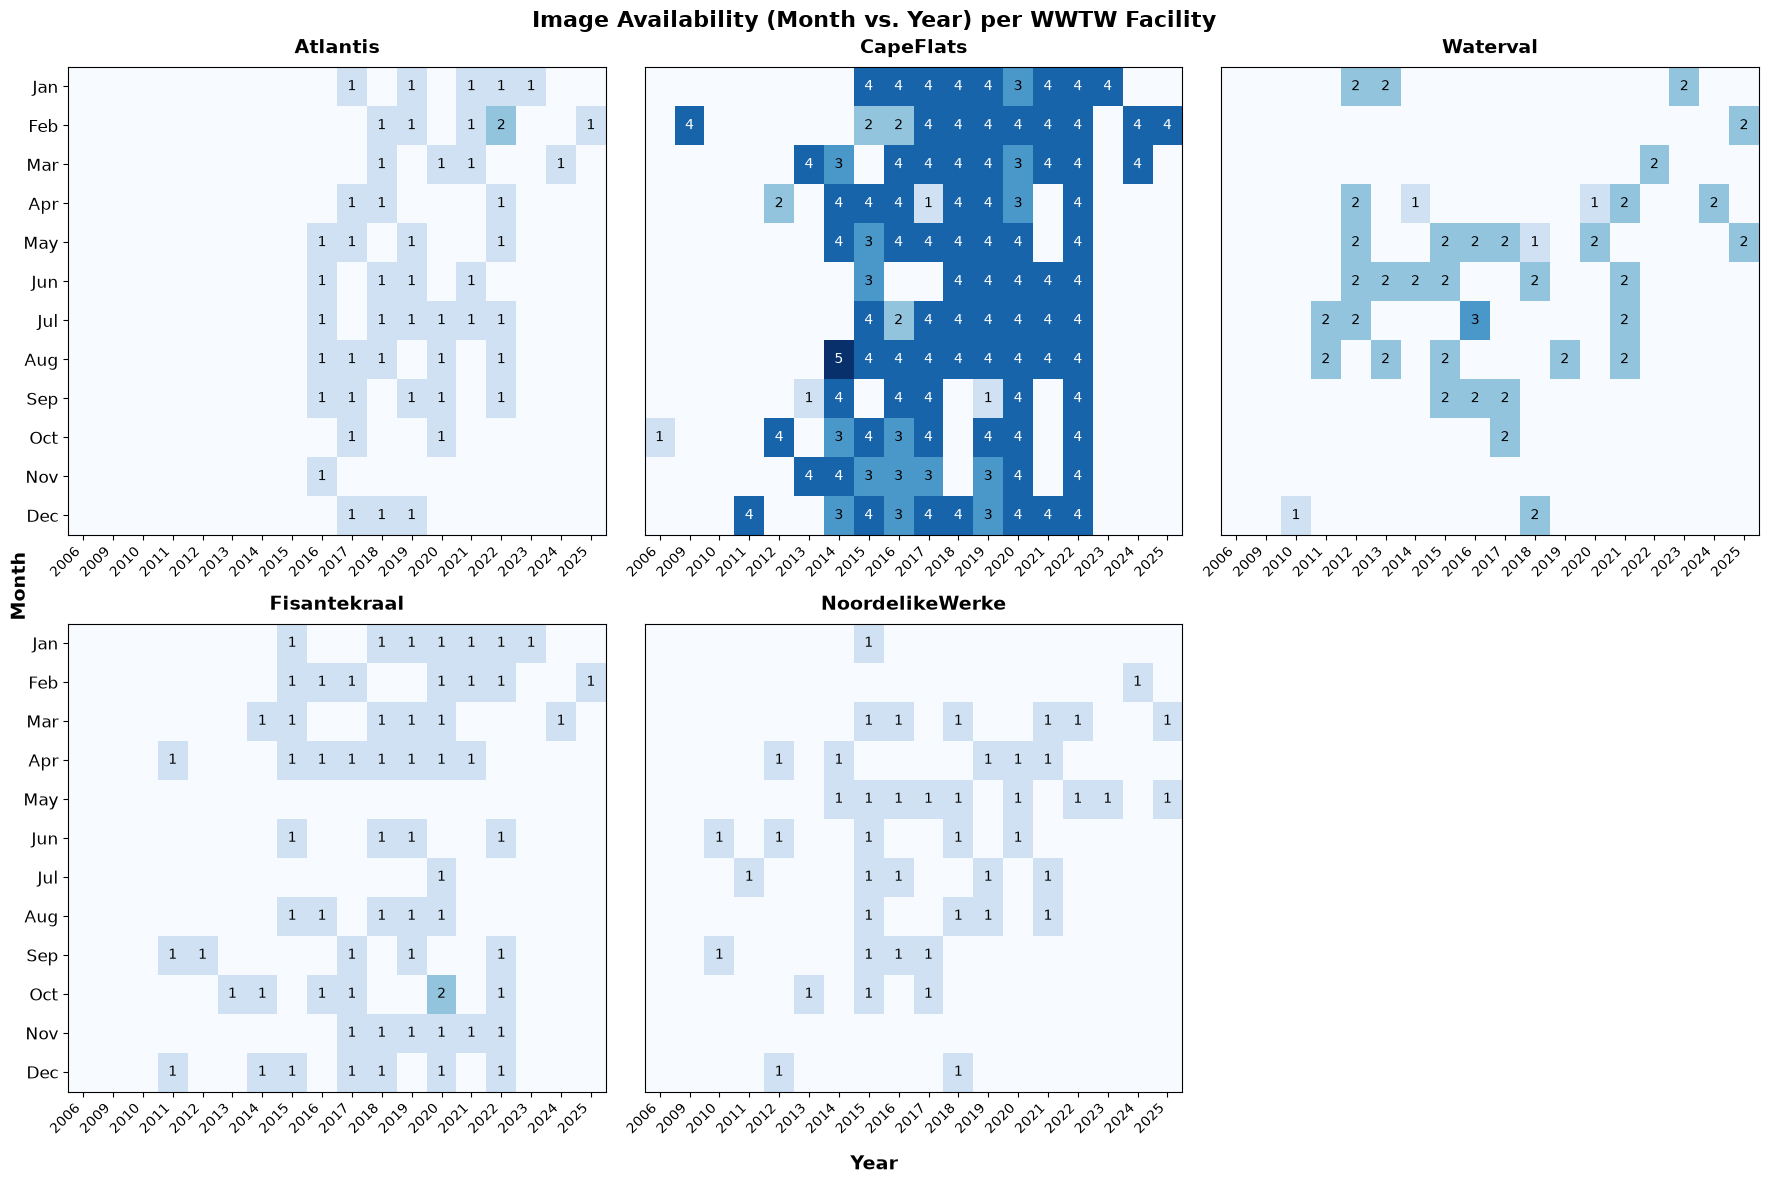

In [2]:
import re
import calendar
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict

# Setup paths based on your project structure
RAW_DATA_ROOT = Path("../wastewater")
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".tif", ".tiff"}

# Grouping all sub-directories by their main facility
FACILITIES = {
    "Atlantis": [
        "Atlantis/Images"
    ],
    "CapeFlats": [
        "CapeFlats/Images/CF1", 
        "CapeFlats/Images/CF2", 
        "CapeFlats/Images/CF3", 
        "CapeFlats/Images/CF4"
    ],
    "Waterval": [
        "Waterval/Images/Waterval (Top)", 
        "Waterval/Images/Waterval (Bottom)",
        "Waterval/Images/Waterval (Overview)"
    ],
    "Fisantekraal": [
        "Fisantekraal/Images"
    ],
    "NoordelikeWerke": [
        "NoordelikeWerke/Images"
    ]
}

# Dictionary to hold year-month counts per facility
temporal_counts = {fac: defaultdict(lambda: np.zeros(12, dtype=int)) for fac in FACILITIES}
all_years = set()

# 1. Parse filenames and aggregate counts
for facility, subdirs in FACILITIES.items():
    for subdir in subdirs:
        dir_path = RAW_DATA_ROOT / subdir
        if not dir_path.exists():
            continue
            
        for filepath in dir_path.iterdir():
            if filepath.suffix.lower() in IMAGE_EXTENSIONS:
                month, year = None, None
                
                # Try Pattern 1: MM_YYYY (e.g., 03_2024.jpg)
                match_mm_yyyy = re.search(r"(\d{2})_(\d{4})", filepath.name)
                
                # Try Pattern 2: _YYYYMM (e.g., capeflats2_200902.jpg)
                match_yyyy_mm = re.search(r"_(\d{4})(\d{2})", filepath.name)

                # Try Pattern 3: YYYY_MM (e.g., Fisantekraal 2020_05.jpg)
                match_yyyy_mm_underscore = re.search(r"(\d{4})_(\d{2})", filepath.name)

                # Try Pattern 4: YYYY MM (e.g., Northern Works 2020 05.jpg)
                match_yyyy_mm_space = re.search(r"(\d{4})\s(\d{2})", filepath.name)

                if match_mm_yyyy:
                    month = int(match_mm_yyyy.group(1))
                    year = int(match_mm_yyyy.group(2))
                elif match_yyyy_mm:
                    year = int(match_yyyy_mm.group(1))
                    month = int(match_yyyy_mm.group(2))
                elif match_yyyy_mm_underscore:
                    year = int(match_yyyy_mm_underscore.group(1))
                    month = int(match_yyyy_mm_underscore.group(2))
                elif match_yyyy_mm_space:
                    year = int(match_yyyy_mm_space.group(1))
                    month = int(match_yyyy_mm_space.group(2))
                
                # If valid dates were found, increment the count
                if month and year and 1 <= month <= 12:
                    temporal_counts[facility][year][month - 1] += 1
                    all_years.add(year)

# 2. Plotting the heatmaps
if not all_years:
    print("No valid images found matching the expected date patterns.")
else:
    sorted_years = sorted(list(all_years))
    months = [calendar.month_abbr[m] for m in range(1, 13)]

    # Create a 2x3 grid of subplots (6 total, we'll hide the last one)
    fig, axes = plt.subplots(2, 3, figsize=(18, 12), sharey=True)
    axes = axes.flatten() # Flatten to make indexing easier
    
    # Calculate global max for consistent color mapping across all plots
    global_max = max(
        count 
        for fac_data in temporal_counts.values() 
        for year_array in fac_data.values() 
        for count in year_array
    )

    for i, (facility, data) in enumerate(temporal_counts.items()):
        # Build a 2D array for the heatmap: rows = months, cols = years
        heatmap_data = np.zeros((12, len(sorted_years)), dtype=int)
        for y_idx, year in enumerate(sorted_years):
            heatmap_data[:, y_idx] = data[year]
        
        ax = axes[i]
        im = ax.imshow(heatmap_data, cmap="Blues", aspect='auto', vmin=0, vmax=global_max)
        
        # Axis formatting
        ax.set_title(f"{facility}", fontsize=14, weight='bold', pad=10)
        ax.set_xticks(np.arange(len(sorted_years)))
        ax.set_xticklabels(sorted_years, rotation=45, ha='right')
        
        # Only show y-axis labels on the leftmost plots of each row
        if i % 3 == 0:
            ax.set_yticks(np.arange(12))
            ax.set_yticklabels(months, fontsize=12)
        else:
            ax.tick_params(axis='y', which='both', left=False, labelleft=False)
            
        # Add text annotations inside the heatmap cells
        for y_idx in range(len(sorted_years)):
            for m_idx in range(12):
                val = heatmap_data[m_idx, y_idx]
                if val > 0:
                    text_color = "white" if val > (global_max * 0.6) else "black"
                    ax.text(y_idx, m_idx, str(val),
                            ha="center", va="center", color=text_color, fontsize=10)

    # Hide the 6th, unused subplot
    axes[5].axis('off')

    # Shared labels and title
    fig.supxlabel('Year', fontsize=14, weight='bold')
    fig.supylabel('Month', fontsize=14, weight='bold')
    fig.suptitle('Image Availability (Month vs. Year) per WWTW Facility', fontsize=16, weight='bold', y=0.98)
    
    plt.tight_layout()
    plt.show()

<h1>Summary Table</h1>

## Class balance (train split)

  Dysfunctional  : 561
  Functional     : 482
  Suboptimal     : 153


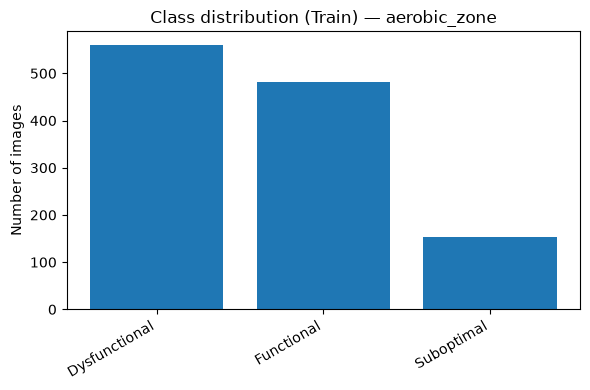

In [3]:
counts = np.bincount([label for _, label in train_ds.samples], minlength=num_classes)
for name, count in zip(class_names, counts):
    print(f"  {name:15s}: {count}")

plt.figure(figsize=(6, 4))
plt.bar(class_names, counts)
plt.ylabel("Number of images")
plt.title(f"Class distribution (Train) — {COMPONENT}")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## Per-facility class breakdown

Image counts per class, split out by facility/unit (Atlantis, Cape Flats 1-4, Waterval Top/Bottom, Fisantekraal, Noordelike Werke), for the full prepared dataset in `cnn_dataset/`. Facility and unit are parsed from the crop filename written by `prep.py`.

In [4]:
import re
import pandas as pd
from pathlib import Path
from collections import defaultdict

DATASET_ROOT = Path("../cnn_dataset")
COMPONENTS = ["aerobic_zone", "clarifier"]

# Every facility/unit the pipeline should always account for, even if a
# given component/class has zero crops for one of them. Order matches the
# thesis summary tables (Table 4.2 / 4.3).
ALL_UNITS = [
    "Atlantis",
    "Cape Flats 1", "Cape Flats 2", "Cape Flats 3", "Cape Flats 4",
    "Waterval Top", "Waterval Bottom",
    "Fisantekraal",
    "NoordelikeWerke",
]


def parse_facility_unit(filename):
    """Map a crop filename (as written by prep.py, e.g.
    'CapeFlats_Images-CF2_<stem>_r0.jpg' or
    'Waterval_Images-Waterval_(Top)_<stem>_r0.jpg') to a facility/unit label
    matching ALL_UNITS above. Falls back to the raw facility token for
    anything unrecognised, so nothing silently disappears from the table.
    """
    if filename.startswith("CapeFlats"):
        m = re.search(r"CF([1-4])", filename)
        if m:
            return "CapeFlats", f"Cape Flats {m.group(1)}"
        return "CapeFlats", "CapeFlats (unit unknown)"

    if filename.startswith("Waterval"):
        if re.search(r"Top", filename, re.IGNORECASE):
            return "Waterval", "Waterval Top"
        if re.search(r"Bottom", filename, re.IGNORECASE):
            return "Waterval", "Waterval Bottom"
        return "Waterval", "Waterval (unit unknown)"

    # Atlantis, Fisantekraal, NoordelikeWerke each have a single unit, so the
    # facility name itself (the first underscore-delimited token) is the row.
    facility = filename.split("_")[0]
    return facility, facility


def facility_class_table(component):
    """Build a facility/unit x class image-count table for one component,
    mirroring the per-facility summary tables in the thesis (Table 4.2 / 4.3),
    broken down to Cape Flats 1-4 and Waterval Top/Bottom.
    """
    component_dir = DATASET_ROOT / component
    if not component_dir.exists():
        print(f"Directory not found: {component_dir}")
        return None

    classes = sorted([d.name for d in component_dir.iterdir() if d.is_dir()])
    if not classes:
        print(f"No classes found in {component_dir}")
        return None

    counts = defaultdict(lambda: defaultdict(int))

    for cls in classes:
        for img_path in (component_dir / cls).glob("*.*"):
            _, unit_label = parse_facility_unit(img_path.name)
            counts[unit_label][cls] += 1

    # Always show every known unit, even ones with 0 crops for this component,
    # then append any unrecognised unit labels so nothing is dropped silently.
    seen_units = set(counts.keys())
    unit_order = ALL_UNITS + sorted(seen_units - set(ALL_UNITS))

    df = pd.DataFrame(0, index=unit_order, columns=classes)
    for unit in unit_order:
        for cls in classes:
            df.loc[unit, cls] = counts[unit].get(cls, 0)

    df.loc["TOTAL"] = df.sum()
    return df


component_tables = {}
for comp in COMPONENTS:
    print(f"\n=== {comp.replace('_', ' ').title()} — image counts per class per facility/unit ===")
    df = facility_class_table(comp)
    component_tables[comp] = df
    if df is not None:
        display(df)


=== Aerobic Zone — image counts per class per facility/unit ===


,Dysfunctional,Functional,Suboptimal
Atlantis,14,58,19
Cape Flats 1,113,44,37
Cape Flats 2,146,21,21
Cape Flats 3,137,15,32
Cape Flats 4,166,12,22
Waterval Top,85,344,15
Waterval Bottom,144,199,77
Fisantekraal,0,0,0
NoordelikeWerke,0,0,0
TOTAL,805,693,223



=== Clarifier — image counts per class per facility/unit ===


,Dysfunctional,Empty,Functional,Scum
Atlantis,0,2,36,52
Cape Flats 1,31,60,177,76
Cape Flats 2,60,33,181,90
Cape Flats 3,19,19,209,121
Cape Flats 4,41,1,129,229
Waterval Top,71,0,69,0
Waterval Bottom,7,0,26,111
Fisantekraal,19,9,106,118
NoordelikeWerke,127,13,113,152
TOTAL,375,137,1046,949


<h1>Class Example</h1>

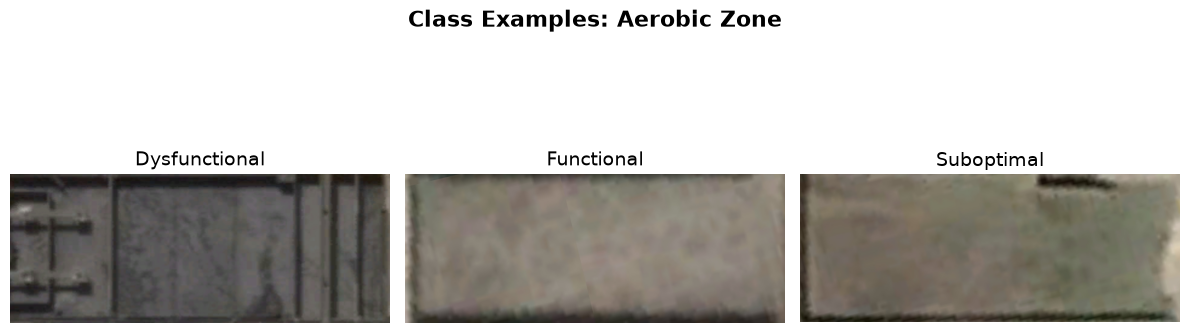

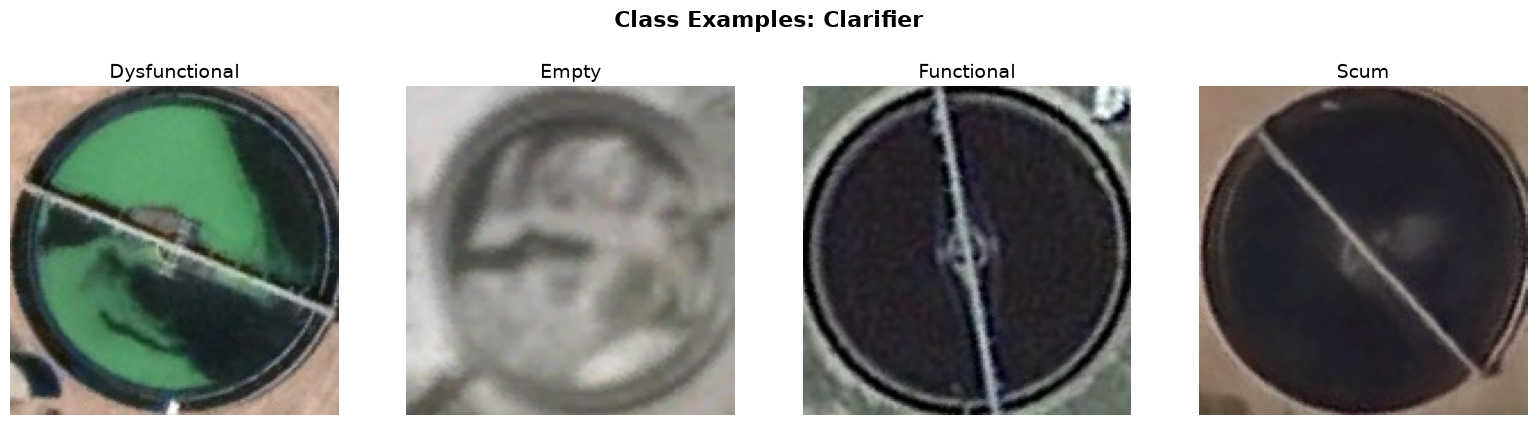

In [5]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

# Set this to your output root directory
DATASET_ROOT = Path("../cnn_dataset")
COMPONENTS = ["aerobic_zone", "clarifier"]

def plot_class_examples(component):
    component_dir = DATASET_ROOT / component
    if not component_dir.exists():
        print(f"Directory not found: {component_dir}")
        return

    # Dynamically find classes (ignoring hidden files)
    classes = sorted([d.name for d in component_dir.iterdir() if d.is_dir()])
    
    if not classes:
        print(f"No classes found in {component_dir}")
        return

    # Create a subplot grid: 1 Row, len(classes) Columns
    fig, axes = plt.subplots(nrows=1, ncols=len(classes), 
                             figsize=(4 * len(classes), 4))
    
    # Handle the edge case if there is only 1 class
    if len(classes) == 1:
        axes = [axes]
        
    fig.suptitle(f"Class Examples: {component.replace('_', ' ').title()}", 
                 fontsize=16, weight='bold', y=1.05)

    for col_idx, cls_name in enumerate(classes):
        cls_dir = component_dir / cls_name
        # Grab all jpg images in this class folder
        all_files = list(cls_dir.glob("*.jpg")) 
        
        ax = axes[col_idx]
        
        if all_files:
            # Pick a random image from this class (ignoring facility)
            img_path = random.choice(all_files)
            img = mpimg.imread(str(img_path))
            ax.imshow(img)
            ax.set_title(cls_name, fontsize=14)
            ax.axis('off')
        else:
            # Completely remove the subplot if the class folder is empty
            ax.remove()
            
    plt.tight_layout()
    plt.show()

# Generate the visual grids for both components
for comp in COMPONENTS:
    plot_class_examples(comp)

## Data source (facility) distribution across splits

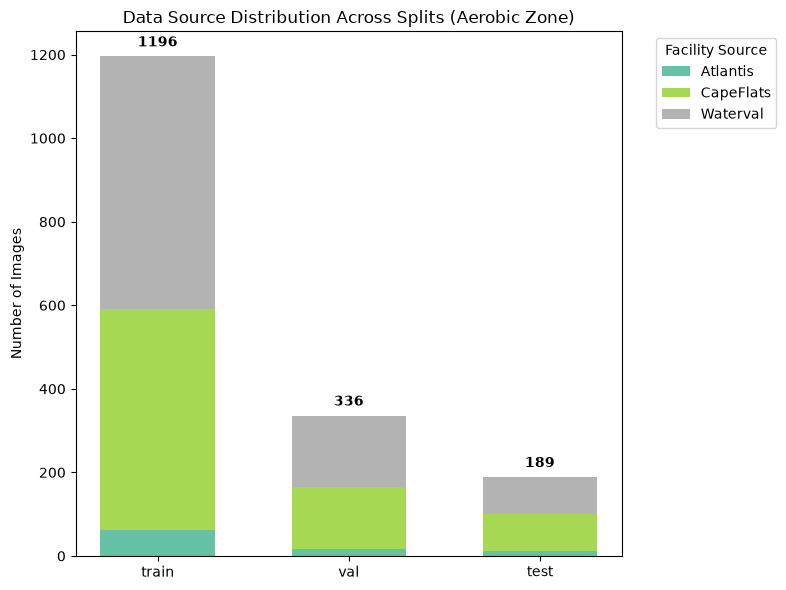

In [6]:
from collections import defaultdict

splits = ['train', 'val', 'test']
split_facility_counts = {split: defaultdict(int) for split in splits}

for split in splits:
    split_dir = data_dir / split
    if not split_dir.exists():
        continue

    for class_dir in split_dir.iterdir():
        if not class_dir.is_dir():
            continue

        for img_path in class_dir.glob("*.*"):
            facility = img_path.name.split('_')[0]
            split_facility_counts[split][facility] += 1

all_facilities = sorted({
    facility
    for split_data in split_facility_counts.values()
    for facility in split_data.keys()
})

plot_data = {facility: [] for facility in all_facilities}

for split in splits:
    for facility in all_facilities:
        plot_data[facility].append(split_facility_counts[split].get(facility, 0))

fig, ax = plt.subplots(figsize=(8, 6))

bottoms = np.zeros(len(splits))

colors = plt.cm.Set2(np.linspace(0, 1, len(all_facilities)))

for idx, facility in enumerate(all_facilities):
    counts = np.array(plot_data[facility])
    ax.bar(splits, counts, label=facility, bottom=bottoms, color=colors[idx], width=0.6)
    bottoms += counts

ax.set_ylabel('Number of Images')
ax.set_title(f'Data Source Distribution Across Splits ({COMPONENT.replace("_", " ").title()})')
ax.legend(title="Facility Source", bbox_to_anchor=(1.05, 1), loc='upper left')

for i, total in enumerate(bottoms):
    ax.text(i, total + (max(bottoms)*0.02), f'{int(total)}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## Inspect a training batch (with augmentation applied)

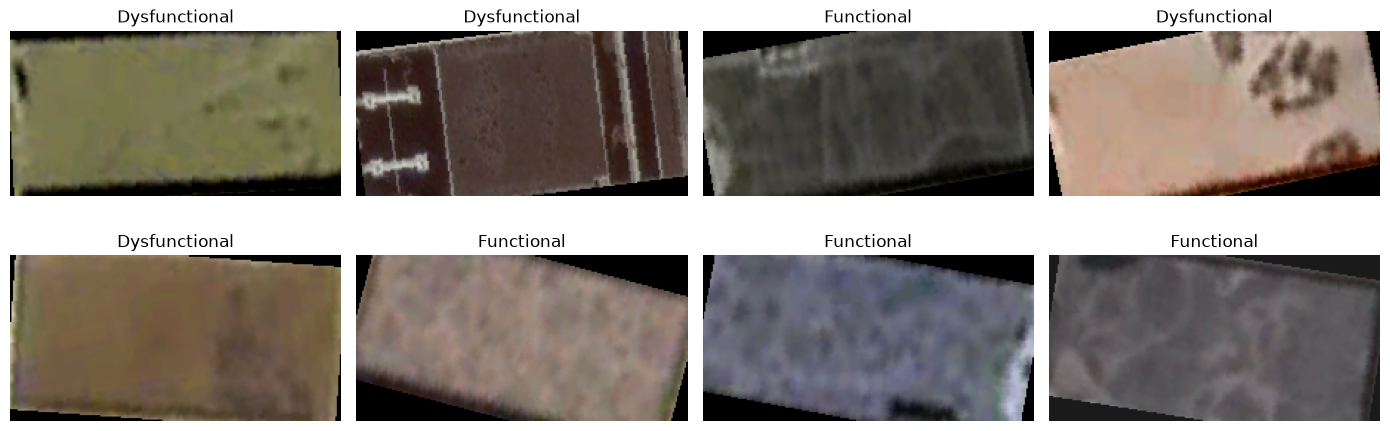

In [7]:
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 4, figsize=(14, 5))
for ax, img, label in zip(axes.flatten(), images, labels):
    ax.imshow(denormalize(img).permute(1, 2, 0).numpy())
    ax.set_title(class_names[label])
    ax.axis("off")
plt.tight_layout()
plt.show()

## Hyperparameter tuning summary (reference)

The grid search / Bayesian-optimization results that `ARCH_HYPERPARAMS` in `wwtw_utils.py` was derived from, for reference.

In [8]:
print_tuning_summary()

Architecture grid search (best H, N per model):
                 hidden_layers (H)  neurons (N)  val_accuracy_%
model                                                          
ResNet-50                        3         1024           97.37
DenseNet-121                     3         2048           96.05
InceptionNet v3                  3         2048           97.70

Bayesian-optimized learning hyperparameters:
                 learning_rate         beta1  step_size_Es  batch_size
model                                                                 
ResNet-50             0.000027  1.788129e-01            34         121
DenseNet-121          0.000274  4.149011e-17             7          14
InceptionNet v3       0.000143  5.190841e-17            21          17
